In [1]:
import pandas as pd

URL = "https://berkeley-earth-temperature.s3.us-west-1.amazonaws.com/Regional/TAVG/france-TAVG-Trend.txt"

df = pd.read_fwf(
    URL,
    comment='%',
    header=None
)

df.columns = [
    "year", "month",
    "anomaly_monthly", "uncertainty_monthly",
    "anomaly_annual", "uncertainty_annual",
    "anomaly_5yr", "uncertainty_5yr",
    "anomaly_10yr", "uncertainty_10yr",
    "anomaly_20yr", "uncertainty_20yr"
]

df.to_csv("france_TAVG_trend.csv", index=False)

print(df.head())
print(df.shape)


   year month anomaly_monthly uncertainty_monthly anomaly_annual  \
0  This     e          ains a               extra          regio   
1  temp    ur           sults               oduce          the B   
2  meth    or           regio                 NaN            NaN   
3     F     e             NaN                 NaN            NaN   
4   The    el          arth m               hod t          tempe   

  uncertainty_annual anomaly_5yr uncertainty_5yr anomaly_10yr  \
0              l sum          la             urf          NaN   
1              keley         ave              ng          NaN   
2                NaN         NaN             NaN          NaN   
3                NaN         NaN             NaN          NaN   
4               ture         tio             rom            e   

  uncertainty_10yr anomaly_20yr uncertainty_20yr  
0              NaN          NaN              NaN  
1              NaN          NaN              NaN  
2              NaN          NaN              Na

In [3]:
# Nettoyage du CSV généré

INPUT_CSV = "france_TAVG_trend.csv"
OUTPUT_CSV = "france_TAVG_trend_clean.csv"

df = pd.read_csv(INPUT_CSV)

# Conversion forcée en numérique
df["year"] = pd.to_numeric(df["year"], errors="coerce")

# Filtrage logique
df_clean = df[df["year"] >= 1850].copy()

# Reset index
df_clean.reset_index(drop=True, inplace=True)

# Export
df_clean.to_csv(OUTPUT_CSV, index=False)

print(f"CSV nettoyé généré : {OUTPUT_CSV}")
print("Nombre de lignes :", len(df_clean))
print("Années couvertes :", df_clean.year.min(), "-", df_clean.year.max())


CSV nettoyé généré : france_TAVG_trend_clean.csv
Nombre de lignes : 2052
Années couvertes : 1850.0 - 2020.0


In [2]:
# Agrégation mensuelle en saisonnière et annuelle
INPUT_CSV = "france_TAVG_trend_clean.csv"
OUTPUT_CSV = "france_TAVG_trend_monthly_seasonal.csv"

# -------------------------------------------------------------------
# 1. Lecture et types
# -------------------------------------------------------------------
df = pd.read_csv(INPUT_CSV)

df["year"] = df["year"].astype(int)
df["month"] = df["month"].astype(int)
df["anomaly_monthly"] = pd.to_numeric(df["anomaly_monthly"], errors="coerce")

# -------------------------------------------------------------------
# 2. Pivot
# -------------------------------------------------------------------
month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

df["month_name"] = df["month"].map(month_map)

pivot = (
    df.pivot(index="year", columns="month_name", values="anomaly_monthly")
      .reset_index()
)

# -------------------------------------------------------------------
# 3. Agrégations STRICTES (sans min_count)
# -------------------------------------------------------------------

months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

# J-D
jd = pivot[months].mean(axis=1)
jd[pivot[months].count(axis=1) < 12] = pd.NA
pivot["J-D"] = jd

# Décembre année N-1
pivot["Dec_prev"] = pivot["Dec"].shift(1)

# D-N
dn_months = ["Dec_prev","Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov"]
dn = pivot[dn_months].mean(axis=1)
dn[pivot[dn_months].count(axis=1) < 12] = pd.NA
pivot["D-N"] = dn

# DJF
djf_months = ["Dec_prev","Jan","Feb"]
djf = pivot[djf_months].mean(axis=1)
djf[pivot[djf_months].count(axis=1) < 3] = pd.NA
pivot["DJF"] = djf

# MAM
mam_months = ["Mar","Apr","May"]
mam = pivot[mam_months].mean(axis=1)
mam[pivot[mam_months].count(axis=1) < 3] = pd.NA
pivot["MAM"] = mam

# JJA
jja_months = ["Jun","Jul","Aug"]
jja = pivot[jja_months].mean(axis=1)
jja[pivot[jja_months].count(axis=1) < 3] = pd.NA
pivot["JJA"] = jja

# SON
son_months = ["Sep","Oct","Nov"]
son = pivot[son_months].mean(axis=1)
son[pivot[son_months].count(axis=1) < 3] = pd.NA
pivot["SON"] = son

# Nettoyage
pivot.drop(columns=["Dec_prev"], inplace=True)

# -------------------------------------------------------------------
# 4. Ordre final
# -------------------------------------------------------------------
final_columns = [
    "year","Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec",
    "J-D","D-N","DJF","MAM","JJA","SON"
]

pivot = pivot[final_columns]
pivot.rename(columns={"year": "Year"}, inplace=True)

# -------------------------------------------------------------------
# 5. Export
# -------------------------------------------------------------------
pivot.to_csv(OUTPUT_CSV, index=False)

print(f"CSV généré : {OUTPUT_CSV}")
print("Années :", pivot.Year.min(), "-", pivot.Year.max())


CSV généré : france_TAVG_trend_monthly_seasonal.csv
Années : 1850 - 2020


In [ ]:
df = pd.read_csv("france_TAVG_trend_monthly_seasonal.csv")

df.describe()
df.head(3)
df.isna().sum()


Year    0
Jan     0
Feb     0
Mar     0
Apr     0
May     0
Jun     0
Jul     0
Aug     0
Sep     0
Oct     0
Nov     0
Dec     0
J-D     0
D-N     1
DJF     1
MAM     0
JJA     0
SON     0
dtype: int64

In [9]:
# Description de base

df.describe()


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
count,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,171.000000,170.000000,170.000000,171.000000,171.000000,171.000000
mean,1935.000000,-0.048392,-0.052713,-0.034456,0.229520,0.105778,0.239813,0.285947,0.289345,-0.040690,-0.096076,-0.008871,-0.225316,0.053657,0.057042,-0.109790,0.100281,0.271702,-0.048546
std,49.507575,1.626998,1.698422,1.295518,1.071916,1.125673,1.016576,1.147559,1.063984,1.100226,1.193330,1.204279,1.514026,0.647202,0.641235,1.122486,0.817081,0.820360,0.821642
min,1850.000000,-3.895000,-5.880000,-3.657000,-2.163000,-2.852000,-2.090000,-2.063000,-2.332000,-3.203000,-3.551000,-3.195000,-4.341000,-1.303833,-1.328500,-3.340000,-1.665333,-1.245667,-2.090000
25%,1892.500000,-1.033500,-1.266000,-0.893000,-0.492000,-0.734000,-0.425000,-0.538000,-0.516500,-0.712000,-0.899000,-0.880500,-1.099000,-0.344667,-0.383500,-0.885417,-0.427333,-0.327500,-0.593167
50%,1935.000000,0.194000,0.066000,0.007000,0.185000,0.101000,0.172000,0.157000,0.156000,-0.195000,-0.020000,-0.051000,-0.154000,-0.013917,-0.035958,-0.142833,0.000333,0.198667,-0.077667
75%,1977.500000,1.158000,1.095500,0.856000,0.847000,0.931500,0.868500,1.169000,0.850500,0.730000,0.592000,0.669000,0.872000,0.345542,0.412188,0.641833,0.581167,0.721667,0.497667
max,2020.000000,3.308000,3.870000,2.707000,3.683000,2.681000,4.160000,3.967000,4.464000,2.639000,2.958000,2.948000,3.578000,1.894583,1.974833,2.692000,2.458333,3.555333,2.547667


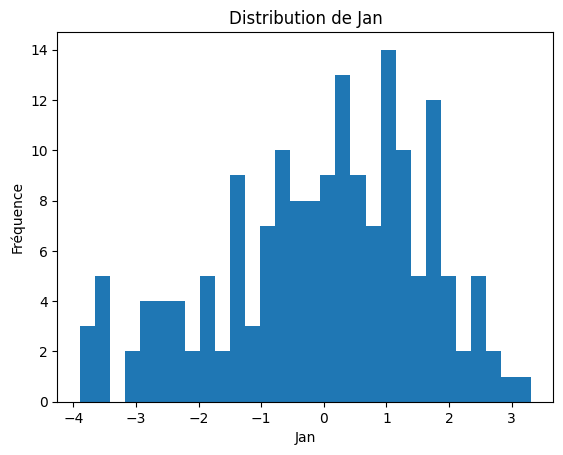

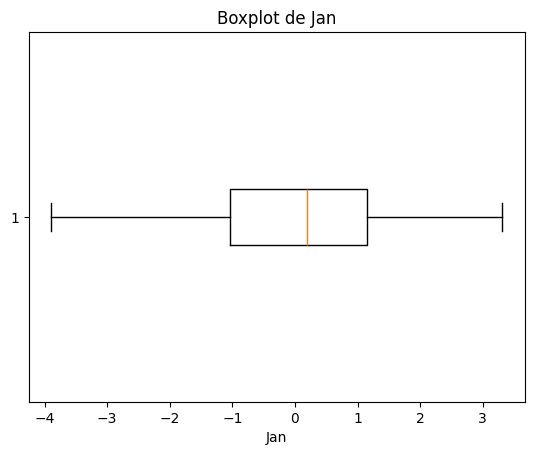

In [16]:
import matplotlib.pyplot as plt

col = "Jan"

plt.figure()
plt.hist(df[col].dropna(), bins=30)
plt.title(f"Distribution de {col}")
plt.xlabel(col)
plt.ylabel("Fréquence")
plt.show()

plt.figure()
plt.boxplot(df[col].dropna(), vert=False)
plt.title(f"Boxplot de {col}")
plt.xlabel(col)
plt.show()


In [17]:
# Détection des outliers avec l'IQR
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df[col] < lower_bound) |
    (df[col] > upper_bound)
]

outliers

outliers.shape[0]


0

In [18]:
print("Min :", df[col].min())
print("Max :", df[col].max())
print("Moyenne :", df[col].mean())
print("Écart-type :", df[col].std())


Min : -3.895
Max : 3.308
Moyenne : -0.04839181286549707
Écart-type : 1.626998255085181
